# Heart Disease Risk Prediction - Milestone 1
## Day 2: Dataset Analysis & Exploration (Framingham Dataset)


In [5]:
!apt install tesseract-ocr -y
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [6]:
#Step 1: Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load dataset (upload framingham.csv to Colab first)
# one process of upoading files here
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("framingham.csv")
df.head()

Saving framingham.csv to framingham.csv


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [8]:
#Step 2: Dataset Overview

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.info()
df.describe(include="all")


Shape: (4240, 16)
Columns: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [9]:
#check datatypes
print(df.dtypes)

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


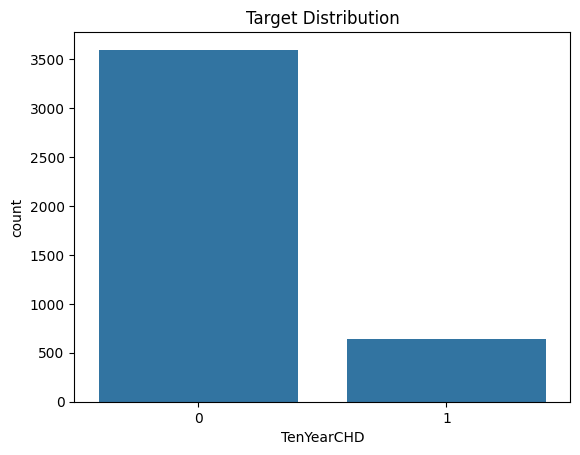

,proportion
TenYearCHD,
0,0.848113
1,0.151887


In [10]:
#Step 3: Target Distribution

target_col = "TenYearCHD"
sns.countplot(x=df[target_col])
plt.title("Target Distribution")
plt.show()

df[target_col].value_counts(normalize=True)

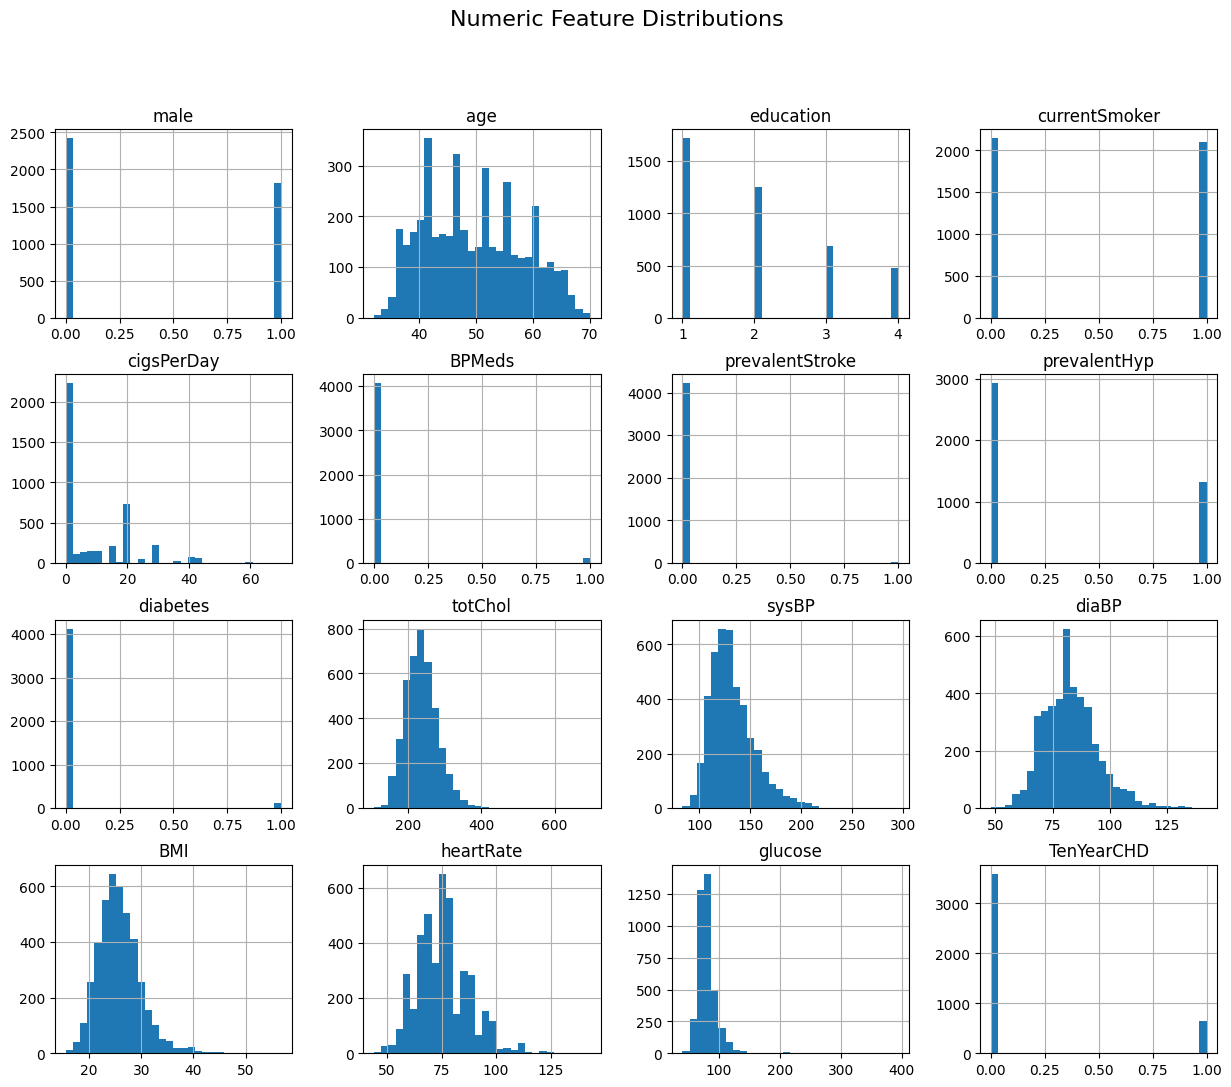

In [11]:
#Step 4: Feature Distributions

numeric_cols = df.select_dtypes(include=np.number).columns

# Histograms
df[numeric_cols].hist(figsize=(15,12), bins=30)
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.show()

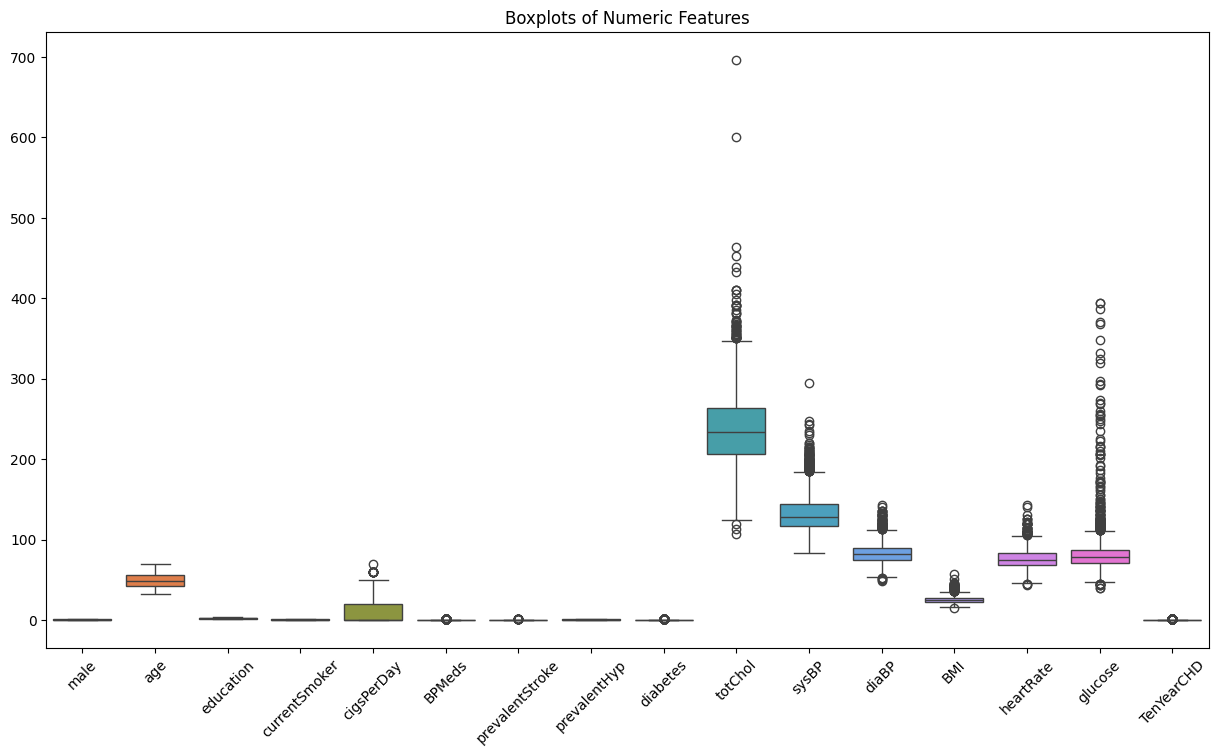

In [12]:
# Boxplots
plt.figure(figsize=(15,8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Features")
plt.show()

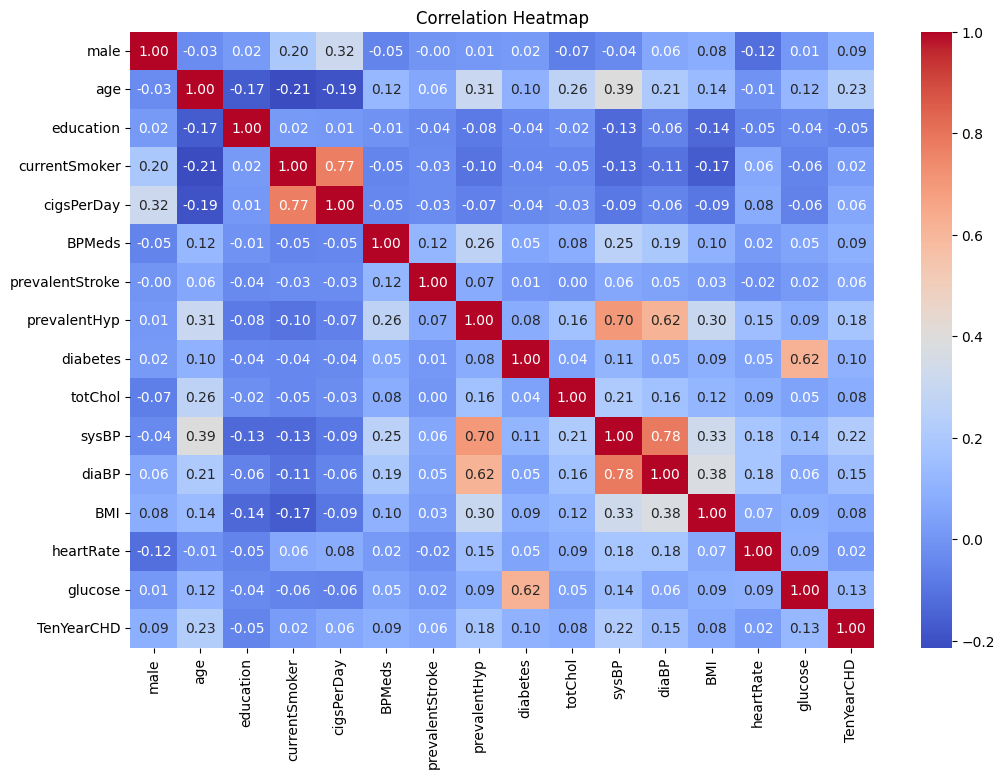

In [13]:
#Step 5: Correlation Analysis

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

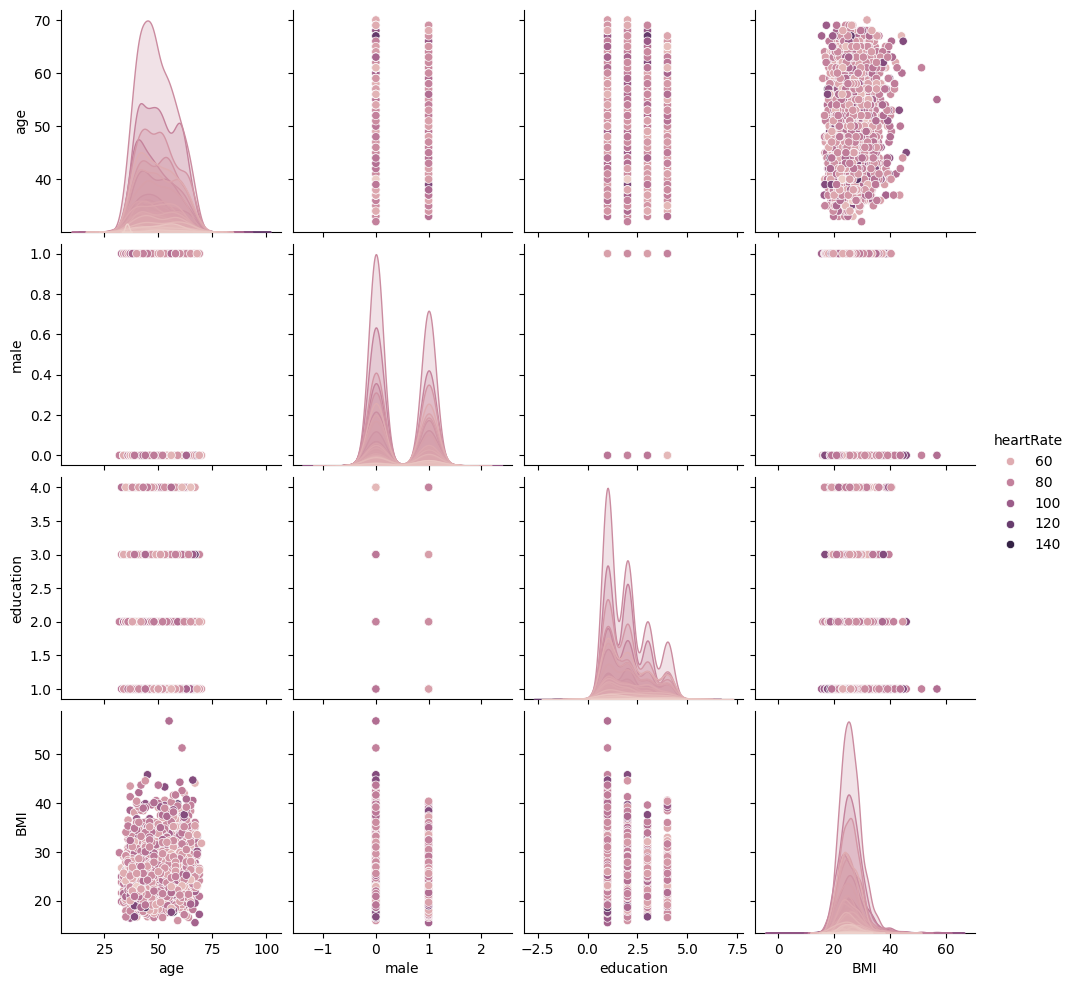

In [14]:
#pairplot
sns.pairplot(df[["age","male","education","BMI","heartRate"]],
             hue="heartRate", diag_kind="kde")
plt.show()


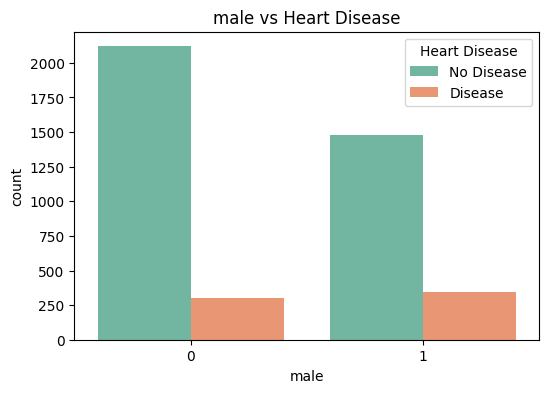

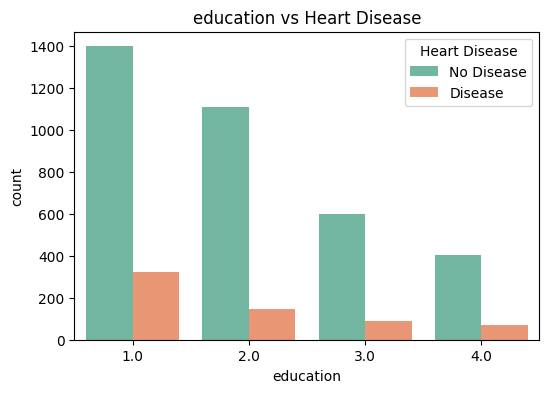

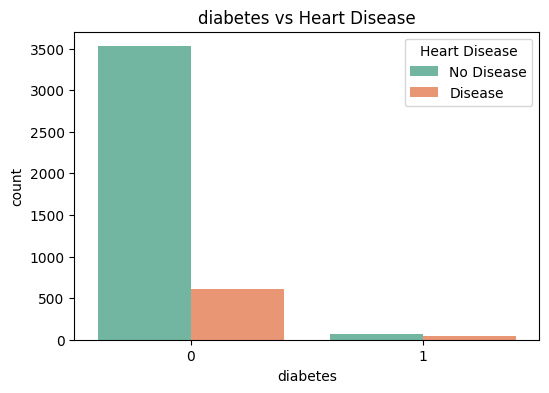

In [15]:
# Categorical/discrete variables in Framingham dataset
categoricals = ["male", "education", "diabetes"]

for col in categoricals:
    plt.figure(figsize=(6,4))
    ax = sns.countplot(x=col, hue="TenYearCHD", data=df, palette="Set2")
    plt.title(f"{col} vs Heart Disease")
    plt.legend(title="Heart Disease", labels=["No Disease","Disease"])
    plt.show()



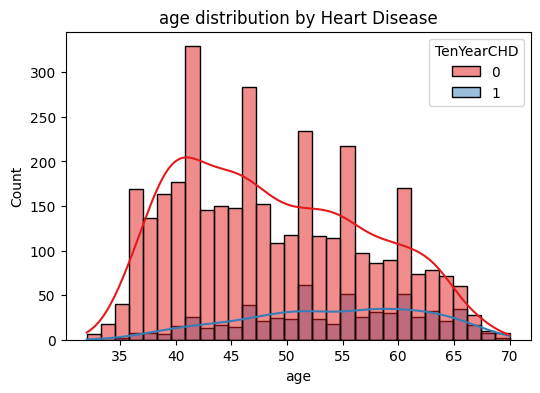

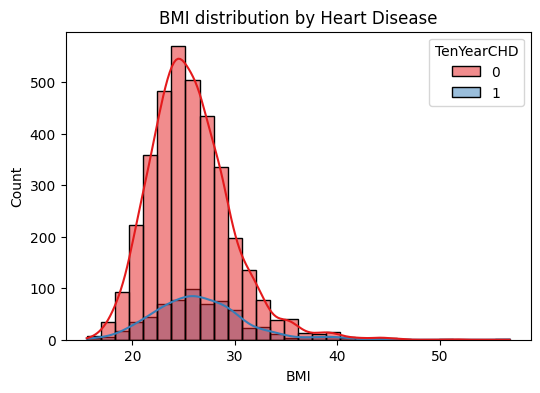

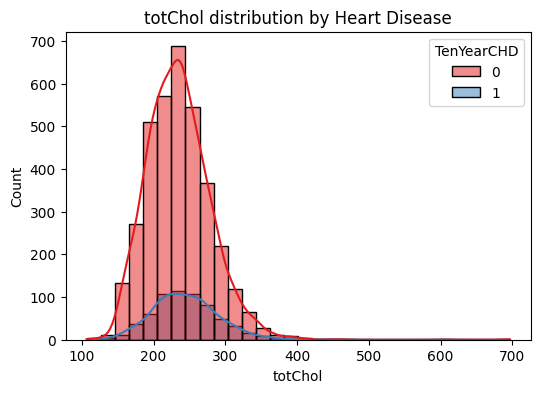

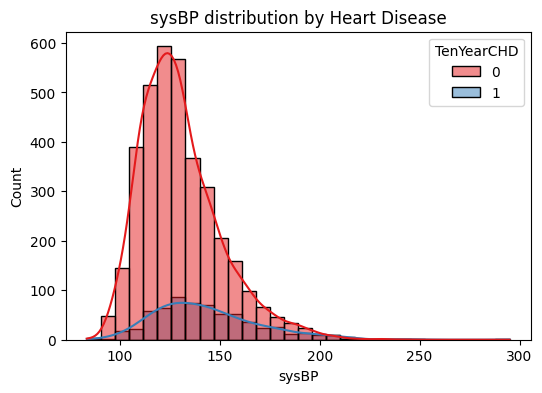

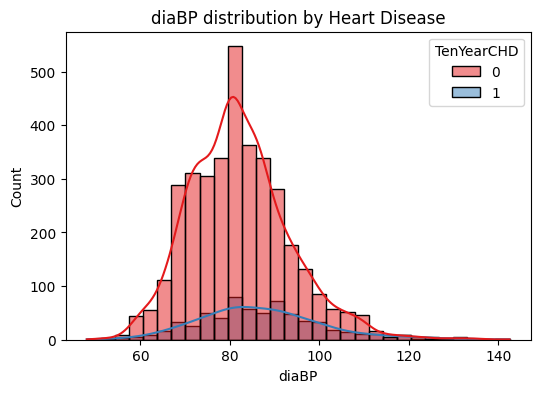

In [16]:
continuous = ["age", "BMI", "totChol", "sysBP", "diaBP"]

for col in continuous:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="TenYearCHD", kde=True, palette="Set1", bins=30)
    plt.title(f"{col} distribution by Heart Disease")
    plt.show()


 Day 3: Data Cleaning & Missing Value Handling (Framingham Dataset)

Missing values per column:
 education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64


<Axes: >

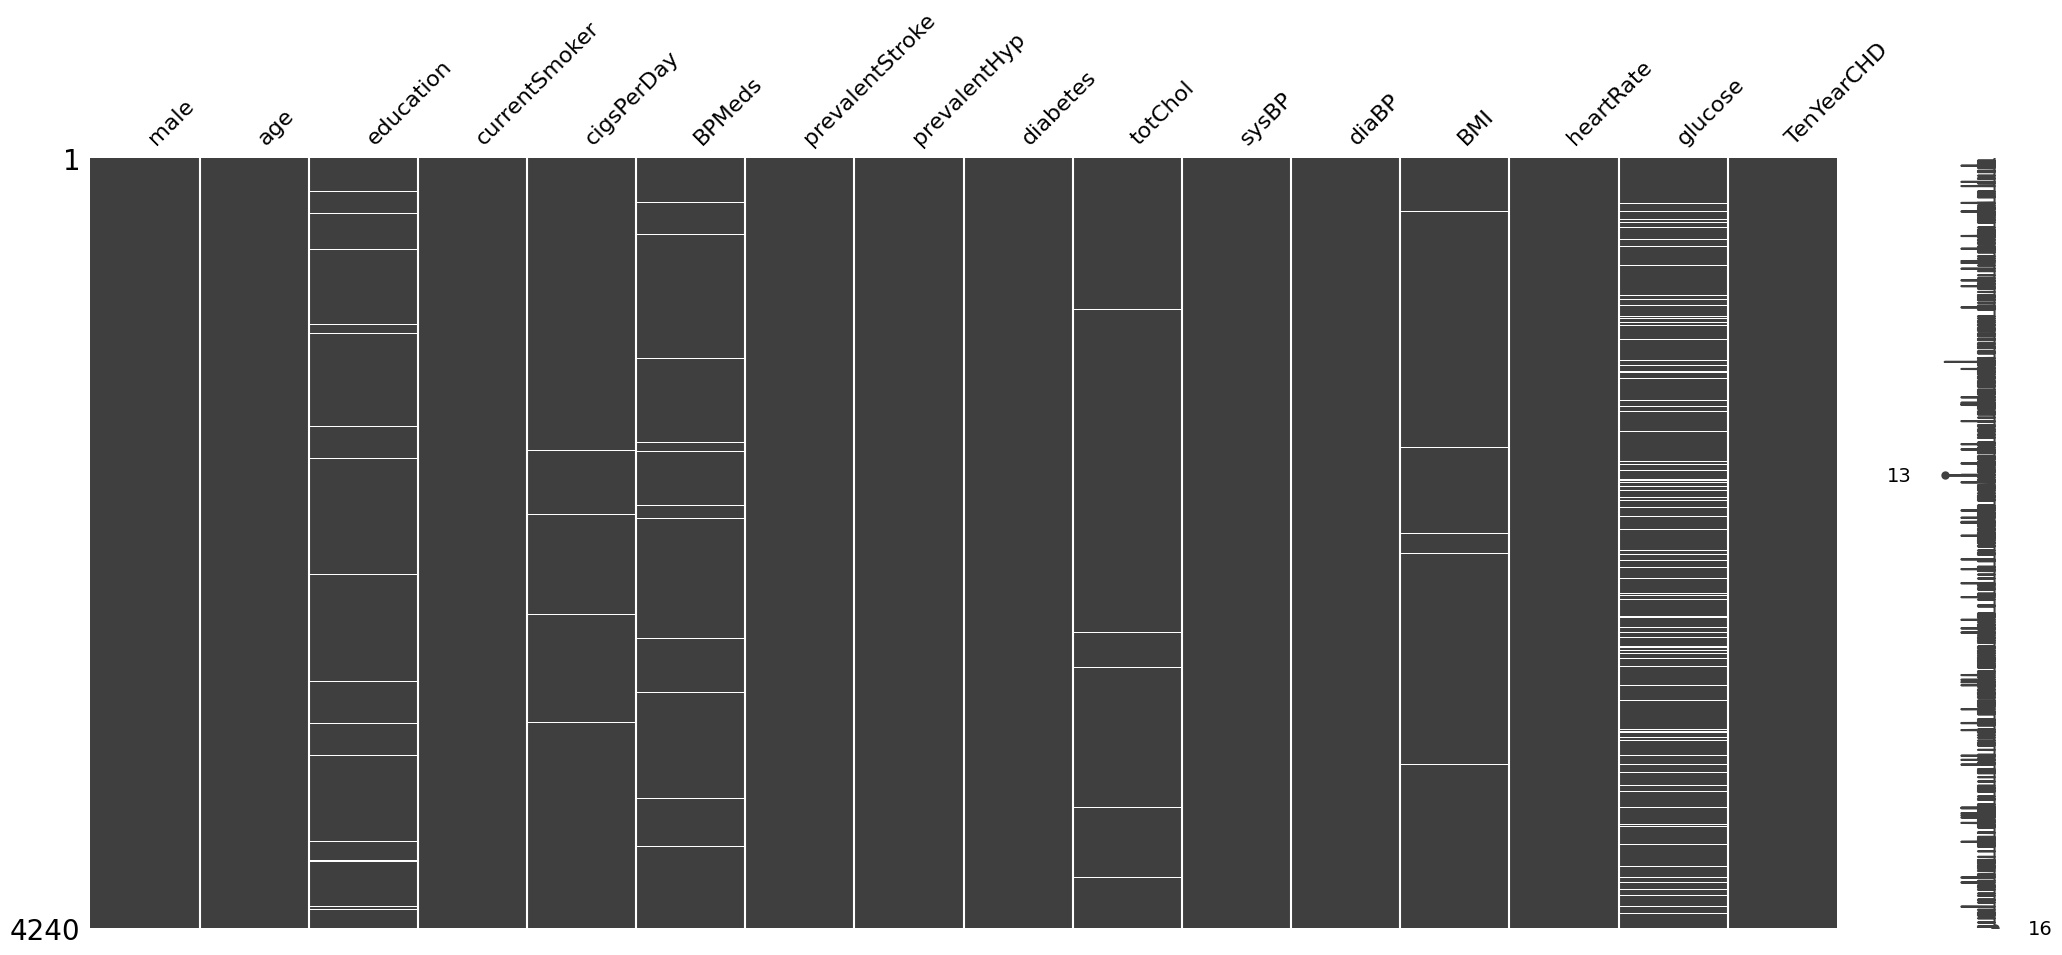

In [17]:
#Missing Value Analysis

missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing>0])

import missingno as msno
msno.matrix(df)

In [18]:
# replace "?" with NaN if present
df = df.replace("?", np.nan)
print(df)

      male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   
4238     1   40        3.0              0         0.0     0.0   
4239     0   39        3.0              1        30.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0             0         0    250.0  121.0

In [19]:
# check missing per column
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64


In [20]:
# class distribution
print(df["TenYearCHD"].value_counts())

TenYearCHD
0    3596
1     644
Name: count, dtype: int64


In [21]:
# ranges of each column
for col in df.columns:
    print(f"{col} → min: {df[col].min()}  max: {df[col].max()}")

male → min: 0  max: 1
age → min: 32  max: 70
education → min: 1.0  max: 4.0
currentSmoker → min: 0  max: 1
cigsPerDay → min: 0.0  max: 70.0
BPMeds → min: 0.0  max: 1.0
prevalentStroke → min: 0  max: 1
prevalentHyp → min: 0  max: 1
diabetes → min: 0  max: 1
totChol → min: 107.0  max: 696.0
sysBP → min: 83.5  max: 295.0
diaBP → min: 48.0  max: 142.5
BMI → min: 15.54  max: 56.8
heartRate → min: 44.0  max: 143.0
glucose → min: 40.0  max: 394.0
TenYearCHD → min: 0  max: 1


In [22]:
# unique categories for categorical columns
for col in ["male", "heartRate", "glucose", "prevalentHyp", "diabetes", "BMI", "education", "BPMeds"]:
    print(f"{col}: {df[col].unique()}")

male: [1 0]
heartRate: [ 80.  95.  75.  65.  85.  77.  60.  79.  76.  93.  72.  98.  64.  70.
  71.  62.  73.  90.  96.  68.  63.  88.  78.  83. 100.  67.  84.  57.
  50.  74.  86.  55.  92.  66.  87. 110.  81.  56.  89.  82.  48. 105.
  61.  54.  69.  52.  94. 140. 130.  58. 108. 104.  91.  53.  nan 106.
  59.  51. 102. 107. 112. 125. 103.  44.  47.  45.  97. 122. 120.  99.
 115. 143. 101.  46.]
glucose: [ 77.  76.  70. 103.  85.  99.  78.  79.  88.  61.  64.  84.  nan  72.
  89.  65. 113.  75.  83.  66.  74.  63.  87. 225.  90.  80. 100. 215.
  98.  62.  95.  94.  55.  82.  93.  73.  45. 202.  68.  97. 104.  96.
 126. 120. 105.  71.  56.  60. 117. 102.  58.  92. 109.  86. 107.  54.
  67.  69.  57.  91. 132. 150.  59.  81. 115. 140. 112. 118. 143. 114.
 160. 110. 123. 108. 145. 122. 137. 106. 127. 205. 130. 101.  47.  53.
 216. 163. 144. 116. 121. 172. 124. 111.  40. 186. 223. 325.  44. 156.
 268.  50. 274. 292. 255. 136. 206. 131. 148. 297.  43. 173.  48. 386.
 155. 147. 170.  52. 32

In [23]:
#Outlier Detection (IQR method)

numeric_cols = df.select_dtypes(include=np.number).columns

def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] < lower) | (data[col] > upper)]

for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers")


cigsPerDay: 12 outliers
BPMeds: 124 outliers
prevalentStroke: 25 outliers
diabetes: 109 outliers
totChol: 56 outliers
sysBP: 126 outliers
diaBP: 77 outliers
BMI: 97 outliers
heartRate: 76 outliers
glucose: 188 outliers
TenYearCHD: 644 outliers


In [24]:
#handling outliers (using clipping)
from scipy import stats

# Define numeric_cols
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)

print(df)

      male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   
4238     1   40        3.0              0         0.0     0.0   
4239     0   39        3.0              1        30.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0             0         0    250.0  121.0

In [25]:
#Missing Value Imputation

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ["float64","int64"]:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
print("Missing values after imputation:", df.isnull().sum().sum())


Missing values after imputation: 0


/tmp/ipython-input-2049149714.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [26]:
#Outlier Handling

for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)


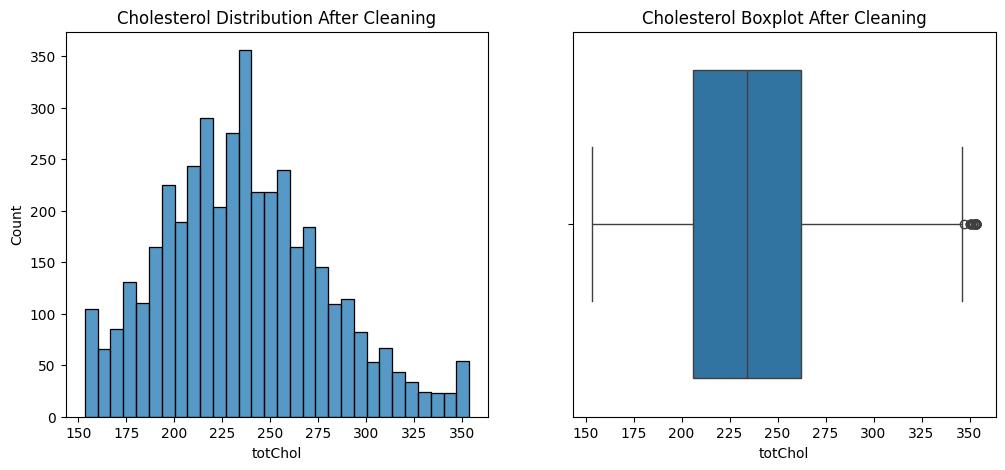

In [27]:
#Before/After Comparison

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.histplot(df['totChol'], bins=30, ax=axes[0])
axes[0].set_title("Cholesterol Distribution After Cleaning")

sns.boxplot(x=df['totChol'], ax=axes[1])
axes[1].set_title("Cholesterol Boxplot After Cleaning")
plt.show()

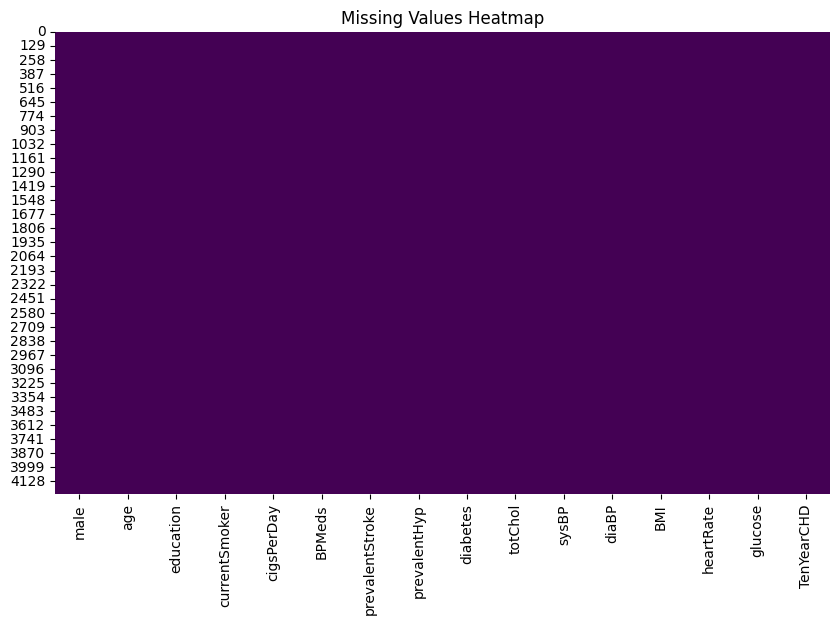

In [28]:
#missing values representational through heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


In [29]:
#Save Cleaned Dataset

df.to_csv("framingham_cleaned.csv", index=False)
print("✅ Cleaned dataset saved as framingham_cleaned.csv")

✅ Cleaned dataset saved as framingham_cleaned.csv


In [30]:
df_cleaned=df[(df['age']>=lower) & (df['age']<=upper)]

In [31]:
#validating dtaa before and after cleaning
print(f"\nOriginal dataframe shape:{df.shape}")
print(f"\nCleaned dataframe shape after removing outliers:{df_cleaned.shape}")


Original dataframe shape:(4240, 16)

Cleaned dataframe shape after removing outliers:(0, 16)


Day 4: OCR System Development

In [32]:
#Install Dependencies

!apt-get install -y tesseract-ocr
!pip install pytesseract opencv-python pillow


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [33]:
#Imports & Setup

import cv2
import pytesseract
from PIL import Image
import numpy as np
import re

# Check version
!tesseract --version

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8


In [66]:
# STEP 1: Install dependencies (only first time)
!apt install tesseract-ocr -y
!pip install pytesseract

import pytesseract
import cv2
import numpy as np
from google.colab import files
import re

# STEP 2: Preprocessing function
def preprocess_image(path):
    """Preprocess image for OCR"""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)   # grayscale
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    # Binarization (thresholding)
    img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    # Noise reduction
    img = cv2.medianBlur(img, 3)
    return img

# STEP 3: OCR extraction
def extract_text_from_image(path):
    img = preprocess_image(path)
    text = pytesseract.image_to_string(img)
    return text

# STEP 4: Regex parsing
def parse_medical_values(text):
    results = {}
    patterns = {
        "blood_pressure": r"Blood Pressure[:\s]*([0-9]{2,3}/[0-9]{2,3})",
        "cholesterol": r"Cholesterol[:\s]*([0-9]{2,3})",
        "fbs": r"Fasting Blood Sugar[:\s]*([0-9]{2,3})",
    }
    for key, pat in patterns.items():
        match = re.search(pat, text, re.IGNORECASE)
        if match:
            results[key] = match.group(1)
    return results

# STEP 5: Upload your reports (e.g. sample_report.png, medical_report_patient2.png)
uploaded = files.upload()

ocr_results = {}

for filename in uploaded.keys():
    text = extract_text_from_image(filename)
    parsed = parse_medical_values(text)
    ocr_results[filename] = parsed

print("OCR Results:", ocr_results)

# STEP 6: Ground truth (manually fill real values you wrote in reports)
ground_truth = {
    "Screenshot 2025-08-25 230130 (2).png": {"blood_pressure": "140/90", "cholesterol": "200", "fbs": "110"},
    "Screenshot 2025-08-25 230311 (2).png": {"blood_pressure": "120/80", "cholesterol": "210", "fbs": "95"},
}


# STEP 7: Accuracy calculation
correct = 0
total = 0

for fname, gt_vals in ground_truth.items():
    pred = ocr_results.get(fname, {})
    for key in gt_vals:
        total += 1
        if pred.get(key) == gt_vals[key]:
            correct += 1

accuracy = (correct / total) * 100 if total > 0 else 0
print(f"\n✅ OCR Accuracy: {accuracy:.2f}%")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


Saving Screenshot 2025-08-25 230130.png to Screenshot 2025-08-25 230130 (2).png
Saving Screenshot 2025-08-25 230311.png to Screenshot 2025-08-25 230311 (2).png
OCR Results: {'Screenshot 2025-08-25 230130 (2).png': {'blood_pressure': '140/90', 'cholesterol': '200', 'fbs': '110'}, 'Screenshot 2025-08-25 230311 (2).png': {'blood_pressure': '120/80', 'cholesterol': '210', 'fbs': '95'}}

✅ OCR Accuracy: 100.00%


Day5:Feature engineering and data transformation

In [62]:
# Step 1: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from scipy import stats

# Load cleaned dataset
df = pd.read_csv("framingham_cleaned.csv")
print(df.shape)
display(df.head())

(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [47]:
#1. Normalize & Standardize Numerical Features
# Select numerical features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns:", numeric_cols)

# Normalization (Min-Max scaling)
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Standardization (Z-score scaling)
std_scaler = StandardScaler()
df_std = df.copy()
df_std[numeric_cols] = std_scaler.fit_transform(df[numeric_cols])

print("Normalized + Standardized Data Ready ✅")


Numeric columns: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']
Normalized + Standardized Data Ready ✅


In [48]:
#Encode Categorical Features
# Example categorical encoding
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

# Label Encoding
label_enc = LabelEncoder()
for col in cat_cols:
    df[col] = label_enc.fit_transform(df[col].astype(str))

# One-Hot Encoding
df_onehot = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Categorical Encoding Done ✅")

Categorical columns: []
Categorical Encoding Done ✅


In [50]:
#Derived Features
# Example derived features
df["age_group"] = pd.cut(df["age"], bins=[20,40,60,80], labels=["Young","Middle","Senior"])
df["cholesterol_risk"] = np.where(df["totChol"]>240,1,0)

df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,age_group,cholesterol_risk
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,Young,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,Middle,1
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,Middle,1
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,Senior,0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,Middle,1


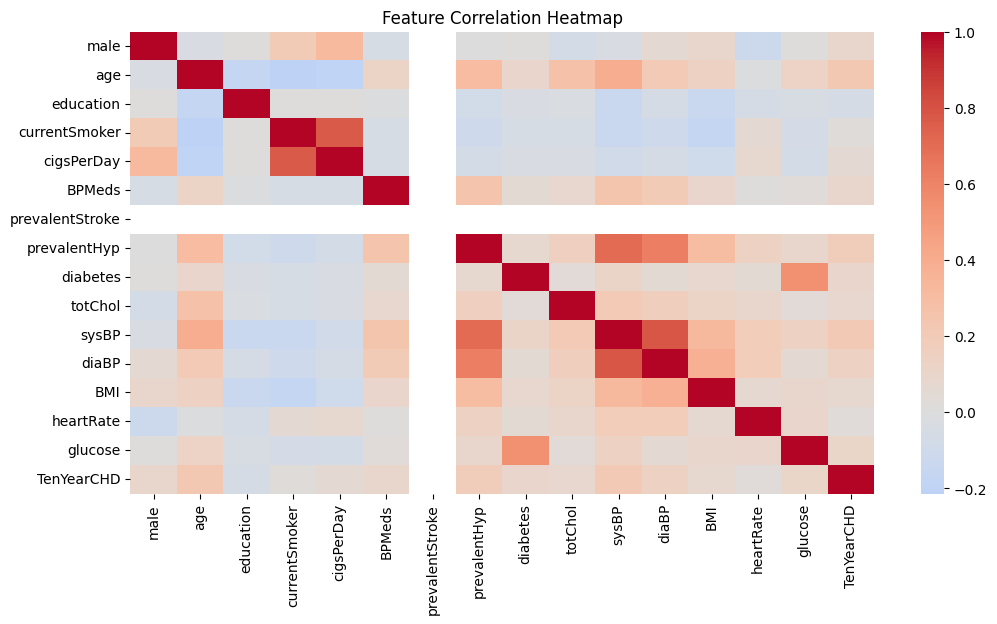

Top 10 Features Selected: ['male', 'cigsPerDay', 'BPMeds', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'glucose']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [5] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [64]:
#Feature Selection (Correlation + Importance)
# Correlation matrix
plt.figure(figsize=(12,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

# Select top K features
X = df.drop(columns=["TenYearCHD", "age"])
y = df["TenYearCHD"]

selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

selected_cols = X.columns[selector.get_support()]
print("Top 10 Features Selected:", selected_cols.tolist())

In [53]:
#Validate Features with Statistical Tests
# Example: t-test between age and TenYearCHD
group1 = df[df["TenYearCHD"]==0]["age"]
group2 = df[df["TenYearCHD"]==1]["age"]

t_stat, p_val = stats.ttest_ind(group1, group2)
print("T-test Age vs CHD:", t_stat, p_val)#

T-test Age vs CHD: -15.0616455873101 5.573313255349969e-50



Day 6: Data Splitting & Integration Testing

In [58]:
#importing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Use transformed data (from Day 5)
X = df.drop(columns=["TenYearCHD"])
y = df["TenYearCHD"]

# Train/Val/Test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (2968, 15) Validation: (636, 15) Test: (636, 15)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8427672955974843

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.91       539
           1       0.36      0.04      0.07        97

    accuracy                           0.84       636
   macro avg       0.61      0.51      0.49       636
weighted avg       0.78      0.84      0.79       636


Confusion Matrix:
 [[532   7]
 [ 93   4]]


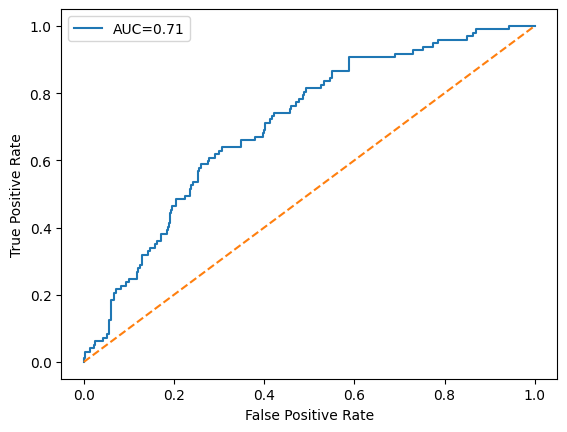

In [60]:
#Train Simple Model & Validate
# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:,1]

# Evaluation
print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_val, y_prob):.2f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [61]:
#Integration Testing
# Final test set evaluation
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:,1]

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_prob))

Test Accuracy: 0.860062893081761
Test ROC AUC: 0.7001736111111111
